In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from datetime import datetime

In [33]:
df = pd.read_csv('sample_dataset.csv', encoding='latin1')
print(df.head())

   Customer ID      Name    Surname Gender   Birthdate  Transaction Amount  \
0       752858      Sean  Rodriguez      F  2002-10-20               35.47   
1        26381  Michelle     Phelps    NaN  1985-10-24             2552.72   
2       305449     Jacob   Williams      M  1981-10-25              115.97   
3       988259    Nathan     Snyder      M  1977-10-26               11.31   
4       764762   Crystal      Knapp      F  1951-11-02               62.21   

         Date               Merchant Name     Category  
0  2023-04-03               Smith-Russell     Cosmetic  
1  2023-07-17      Peck, Spence and Young       Travel  
2  2023-09-20                  Steele Inc     Clothing  
3  2023-01-11  Wilson, Wilson and Russell     Cosmetic  
4  2023-06-13               Palmer-Hinton  Electronics  


In [34]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer ID         50000 non-null  int64  
 1   Name                50000 non-null  object 
 2   Surname             50000 non-null  object 
 3   Gender              44953 non-null  object 
 4   Birthdate           50000 non-null  object 
 5   Transaction Amount  50000 non-null  float64
 6   Date                50000 non-null  object 
 7   Merchant Name       50000 non-null  object 
 8   Category            50000 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 3.4+ MB
None


In [35]:
print(df.isnull().sum())


Customer ID              0
Name                     0
Surname                  0
Gender                5047
Birthdate                0
Transaction Amount       0
Date                     0
Merchant Name            0
Category                 0
dtype: int64


In [36]:
df = df.drop_duplicates()

In [37]:
df['Date'] = pd.to_datetime(df['Date'])
df['Birthdate'] = pd.to_datetime(df['Birthdate'])
print(df.shape)

(50000, 9)


Feature Engineering


In [23]:
today = datetime.today()
df['Age'] = today.year - df['Birthdate'].dt.year

Creating Customer summary


In [16]:
customer_data = df.groupby('Customer ID').agg({
    'Transaction Amount':['sum','mean','count'],
    'Age':'first'
})

customer_data.columns = [
    'Total_Spending',
    'Average_Spending',
    'Purchase_Frequency',
    'Age'
]

customer_data.reset_index(inplace=True)

print(customer_data.head())

   Customer ID  Total_Spending  Average_Spending  Purchase_Frequency  Age
0           29           27.02             27.02                   1   43
1           51         1898.56           1898.56                   1   22
2           54          166.30            166.30                   1   45
3           83          125.85            125.85                   1   75
4           90           18.16             18.16                   1   21


In [ ]:
features = customer_data[
    ['Total_Spending',
     'Average_Spending',
     'Purchase_Frequency',
     'Age']
]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [26]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
customer_data['Cluster'] = kmeans.fit_predict(scaled_features)
print(customer_data.head())

   Customer ID  Total_Spending  Average_Spending  Purchase_Frequency  Age  \
0           29           27.02             27.02                   1   43   
1           51         1898.56           1898.56                   1   22   
2           54          166.30            166.30                   1   45   
3           83          125.85            125.85                   1   75   
4           90           18.16             18.16                   1   21   

   Cluster  
0        2  
1        1  
2        2  
3        0  
4        2  


Analysing customer summary

In [27]:
cluster_summary = customer_data.groupby('Cluster').mean()
print(cluster_summary)

           Customer ID  Total_Spending  Average_Spending  Purchase_Frequency  \
Cluster                                                                        
0        501386.910759      185.961947        185.961947                 1.0   
1        494627.577206     2322.963272       2322.963272                 1.0   
2        499978.123565      191.434023        191.434023                 1.0   
3        499933.141644     1009.559024       1009.559024                 1.0   

               Age  
Cluster             
0        64.316067  
1        49.727416  
2        34.566418  
3        50.064679  


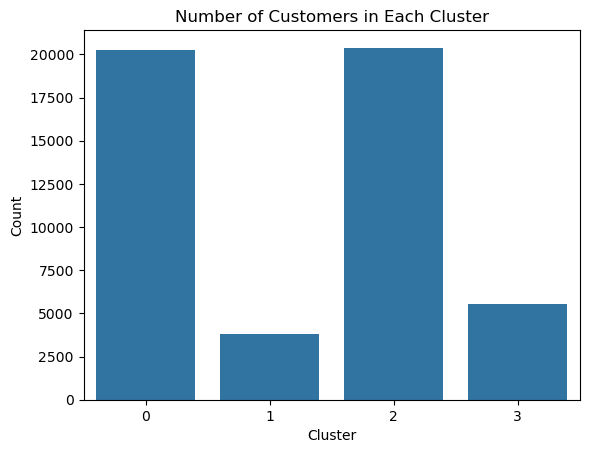

In [31]:
sns.countplot(x='Cluster', data=customer_data)

plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

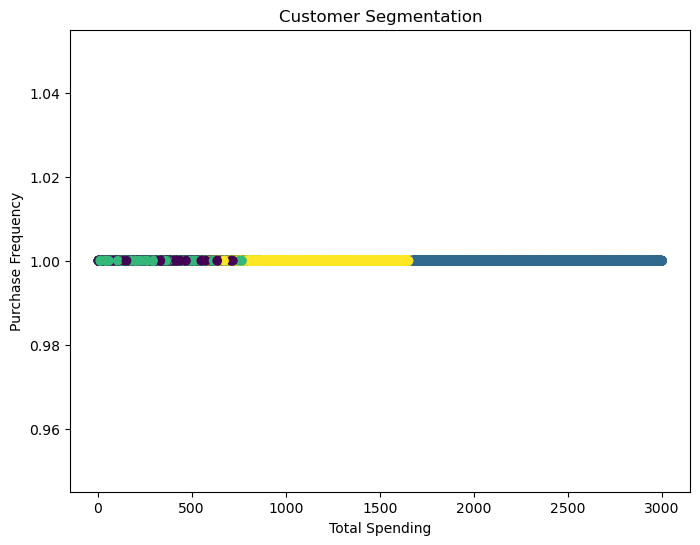

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(
    customer_data['Total_Spending'],
    customer_data['Purchase_Frequency'],
    c=customer_data['Cluster']
)

plt.xlabel('Total Spending')
plt.ylabel('Purchase Frequency')
plt.title('Customer Segmentation')
plt.show()